In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df=pd.read_csv("economic_index_data.csv")
df.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [7]:
df.columns
df.head()


,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


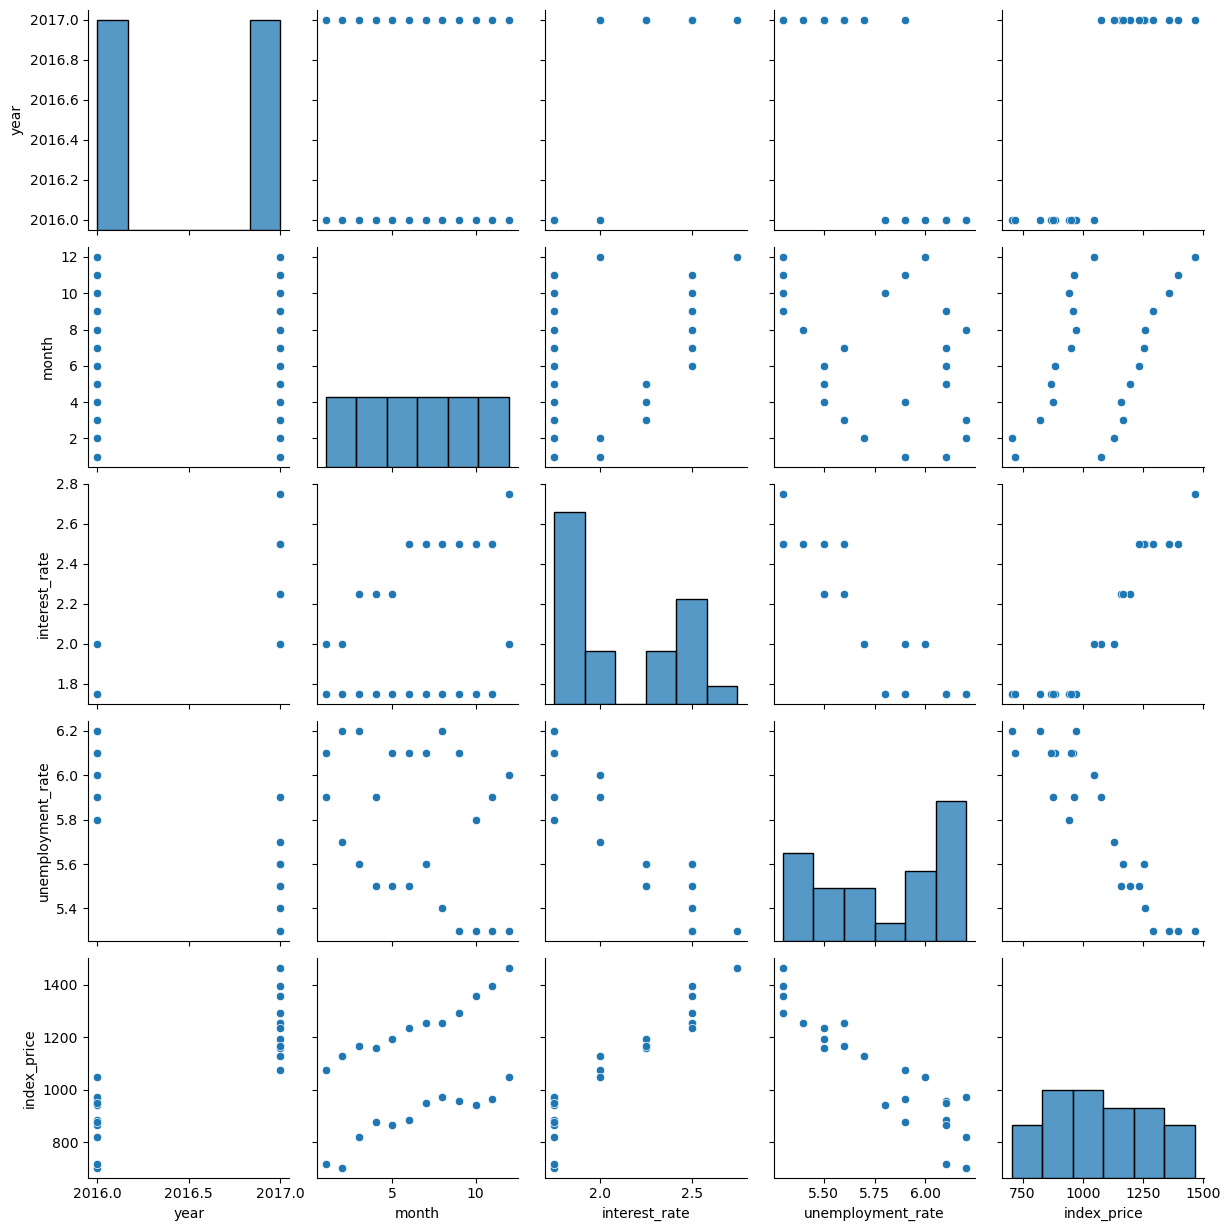

In [8]:
import seaborn as sns
sns.pairplot(df)

In [9]:
df.corr()

,year,month,interest_rate,unemployment_rate,index_price
year,1.000000e+00,7.884865e-14,0.882851,-0.877000,0.863232
month,7.884865e-14,1.000000e+00,0.339526,-0.351189,0.481287
interest_rate,8.828507e-01,3.395257e-01,1.000000,-0.925814,0.935793
unemployment_rate,-8.769997e-01,-3.511891e-01,-0.925814,1.000000,-0.922338
index_price,8.632321e-01,4.812873e-01,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment rate')

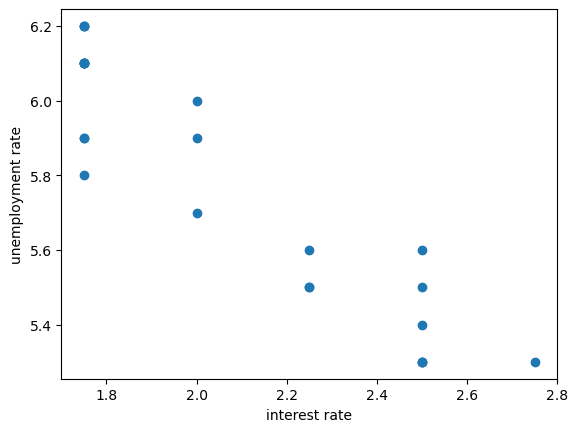

In [10]:
plt.scatter(df['interest_rate'],df['unemployment_rate'])
plt.xlabel("interest rate")
plt.ylabel("unemployment rate")


In [11]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]
X.head()

,year,month,interest_rate,unemployment_rate
0,2017,12,2.75,5.3
1,2017,11,2.50,5.3
2,2017,10,2.50,5.3
3,2017,9,2.50,5.3
4,2017,8,2.50,5.4


In [12]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [13]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

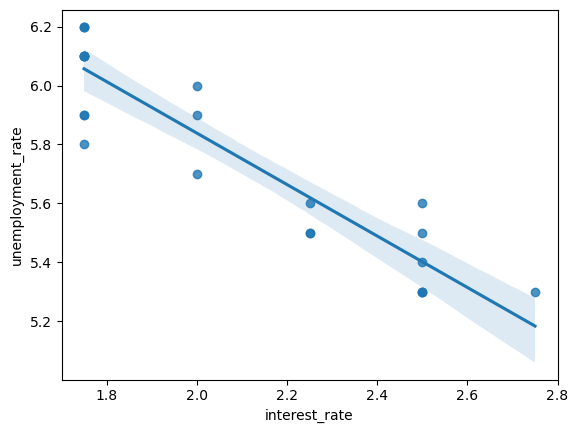

In [14]:
import seaborn as sns
sns.regplot(x=df["interest_rate"],y=df["unemployment_rate"])

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train_scaled,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
regression.fit(X_train_scaled,y_train)
y_pred=regression.predict(X_test_scaled)

Text(0.5, 1.0, 'Actual vs Predicted')

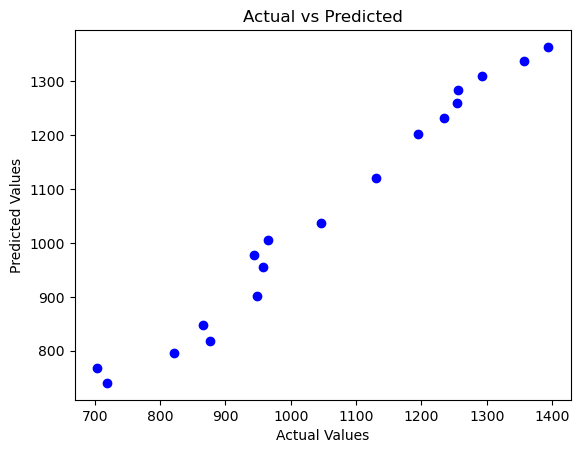

In [19]:
plt.scatter(y_train, regression.predict(X_train_scaled), color='blue')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")



In [ ]:
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,X_train_scaled,y_train,scoring='r2',cv=5)

In [ ]:
np.mean(validation_score)

np.float64(0.8431354650801491)

In [ ]:
y_pred=regression.predict(X_test_scaled)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [ ]:
#performance metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(rmse)

5793.76288771258
59.93578152323556
0.8278978091457142
76.11677139574813


In [ ]:
residuals=y_test-y_pred
residuals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

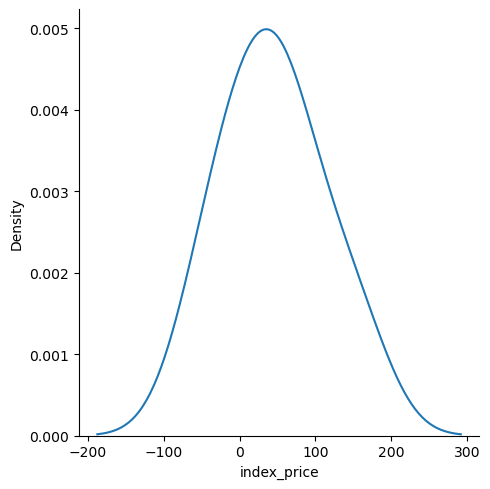

In [ ]:
sns.displot(residuals,kind='kde')

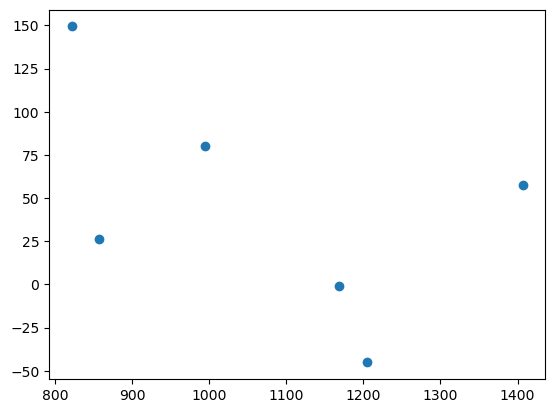

In [ ]:
plt.scatter(y_pred,residuals)

In [ ]:
#OLS technique
import statsmodels.api as sm
model=sm.OLS(y_train,sm.add_constant(X_train_scaled)).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            index_price   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     69.88
Date:                Sun, 17 May 2026   Prob (F-statistic):           2.50e-08
Time:                        13:48:11   Log-Likelihood:                -100.85
No. Observations:                  18   AIC:                             207.7
Df Residuals:                      15   BIC:                             210.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1053.4444     16.941     62.183      0.0

In [ ]:
print(regression.coef_)
print(regression.intercept_)

[  88.27275507 -116.25716066]
1053.4444444444443
